In [17]:
import pandas as pd

In [18]:
#unsupersvised segmentation
rfm = pd.read_csv("/Users/dishasanthosh/Library/CloudStorage/OneDrive-Personal/Uni/Projects/retail-ds-project/data/customer_features.csv")

features = [
    'Recency',
    'Frequency',
    'Monetary',
    'Tenure',
    'AvgOrderValue',
    'FrequencyRate',
    'RevenuePerDay'
]

X_seg = rfm[features]

In [19]:
#scaling the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_seg)


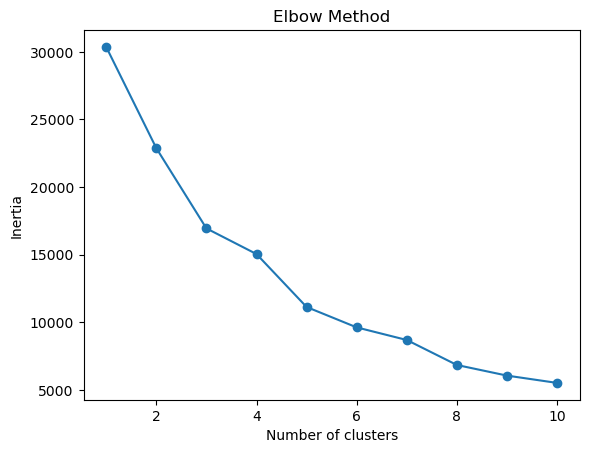

In [20]:
#elbow method -> to find optimal number of clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [21]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

In [22]:
rfm['Cluster'].value_counts()

Cluster
0    2476
1     953
3     908
2       1
Name: count, dtype: int64

In [15]:
cluster_profile = rfm.groupby('Cluster')[features].mean()
print(cluster_profile)

            Recency  Frequency      Monetary      Tenure  AvgOrderValue  \
Cluster                                                                   
0         40.579160   6.506058   3205.950461  222.492730      54.960468   
1         61.846800   1.205666    526.560893    1.031480      51.499748   
2        325.000000   1.000000  77183.600000    0.000000   77183.600000   
3        261.394273   1.401982    434.447611   15.430617      37.620611   

         FrequencyRate  RevenuePerDay  
Cluster                                
0             0.031472      14.197229  
1             1.013380     455.767068  
2             1.000000   77183.600000  
3             0.792474     241.949792  


In [26]:
rfm.groupby('Cluster')['Churn'].mean()

Cluster
0    0.132472
1    0.218258
2    1.000000
3    1.000000
Name: Churn, dtype: float64

Cluster 0 = healthy
Cluster 1 = fragile
Cluster 2/3 = dead